In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from tqdm.notebook import tqdm



In [2]:
# Fix: The original code expected an external notebook's submission.csv that isn't available.
# Use the competition-provided sample_submission.csv to get the correct Id list and columns.
PATH = "../input/alaska2-image-steganalysis"

sample_path = os.path.join(PATH, "sample_submission.csv")
if not os.path.exists(sample_path):
    # fallback to alternate common location in this environment
    sample_path = "../input/sample_submission.csv"

sub = pd.read_csv(sample_path)
# Ensure correct columns exist
assert (
    "Id" in sub.columns and "Label" in sub.columns
), f"Unexpected columns: {sub.columns.tolist()}"
sub["Label"] = sub["Label"].astype(float)




In [3]:
class JPEGImageCompressionRateDeterminer:
    def __call__(self, image_path):
        # Robustness: handle grayscale images and unreadable files without crashing the run.
        try:
            image = imread(image_path)
        except Exception:
            return np.nan

        if image is None:
            return np.nan

        # image can be (H, W) or (H, W, C)
        if image.ndim == 2:
            h, w = image.shape
            c = 1
        else:
            h, w, c = image.shape

        n_bits = h * w * c * 8  # bits/pixel channel
        try:
            image_size = os.stat(image_path).st_size * 8  # bytes -> bits
        except FileNotFoundError:
            return np.nan

        # Keep original heuristic form but ensure finite output
        if n_bits <= 0:
            return np.nan
        return (n_bits - image_size) / n_bits




In [4]:
compression_rate_determiner = JPEGImageCompressionRateDeterminer()

compressions = {}

dir_path = os.path.join(PATH, "Test")
missing = 0
for impath in tqdm(sub.Id.values):
    full_path = os.path.join(dir_path, impath)
    c = compression_rate_determiner(full_path)
    compressions[impath] = c

    # If we can't compute it, leave the label as-is (default 0.0 from sample_submission)
    if pd.notna(c) and c > 0.95:
        sub.loc[sub.Id == impath, "Label"] = 1.0
    if pd.isna(c):
        missing += 1

missing



  0%|          | 0/5000 [00:00<?, ?it/s]

0

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


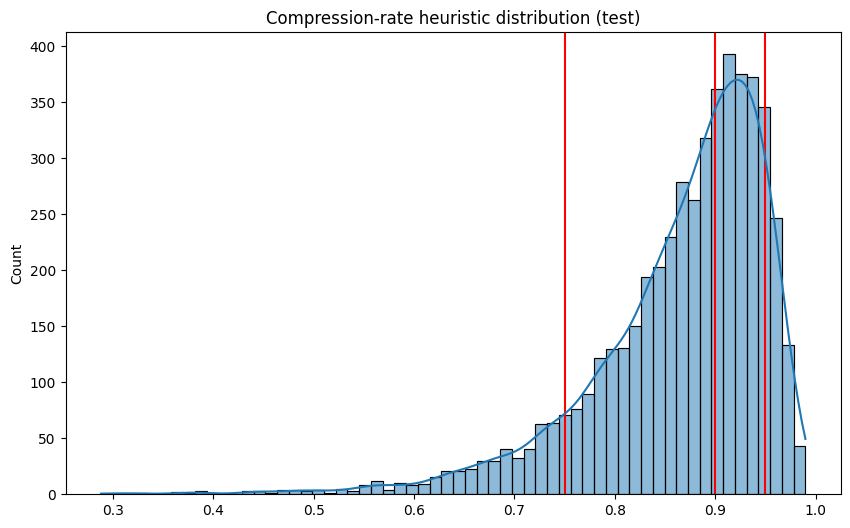

In [5]:
plt.figure(figsize=(10, 6))
plt.axvline(0.75, color="red")
plt.axvline(0.90, color="red")
plt.axvline(0.95, color="red")

vals = pd.Series(list(compressions.values()), dtype="float64").dropna()
# Fix: seaborn.distplot is deprecated; use histplot (keeps the intent the same).
sns.histplot(vals, bins=60, kde=True)
plt.title("Compression-rate heuristic distribution (test)")
plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


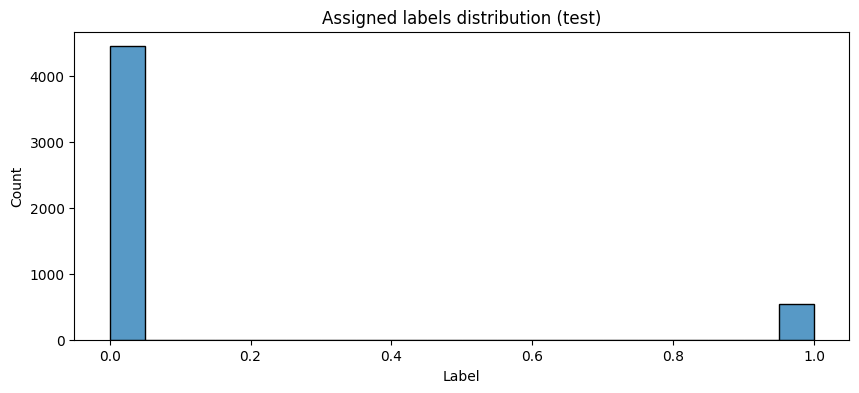

In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(sub["Label"].astype(float), bins=20, kde=False)
plt.title("Assigned labels distribution (test)")
plt.show()



In [7]:
# Ensure submission is valid and written with .csv suffix
sub[["Id", "Label"]].to_csv("submission.csv", index=False)

sub.head()

,Id,Label
0,0001.jpg,0.0
1,0002.jpg,0.0
2,0003.jpg,0.0
3,0004.jpg,0.0
4,0005.jpg,0.0
